In [4]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from src.data import load_data

df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ]
}

# Dictionary to hold merged dataframes
merged_dfs = {}

# Merge with the neighbors found (centroid)
for theme_name, initial_subs in THEMES.items():
    neighbors_centroid_path = f'../data/{theme_name}_centroid_neighbors.csv'

    if os.path.exists(neighbors_centroid_path):
        neighbors_df = pd.read_csv(neighbors_centroid_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_centroid'] = merged_df
    else:
        print(f'File not found :( ')

    # Do the same for max similarity neighbors

    neighbors_maxsim_path = f'../data/{theme_name}_max_similarity_neighbors.csv'

    if os.path.exists(neighbors_maxsim_path):
        neighbors_df = pd.read_csv(neighbors_maxsim_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_maxsim'] = merged_df
    else:
        print(f'File not found :( ')

# Dataframes
sports_centroid_df = merged_dfs.get('sports_centroid')
# politics_centroid_df = merged_dfs.get('politics_centroid')
# gaming_centroid_df = merged_dfs.get('gaming_centroid')
sports_maxsim_df = merged_dfs.get('sports_maxsim')
# politics_maxsim_df = merged_dfs.get('politics_maxsim')
# gaming_maxsim_df = merged_dfs.get('gaming_maxsim')

print("Sports centroid shape:", sports_centroid_df.shape if sports_centroid_df is not None else "Not found")
print("Sports max similarity shape:", sports_maxsim_df.shape if sports_maxsim_df is not None else "Not found")

features = [
    "Number of characters",
    "Number of characters without counting white space",
    "Fraction of alphabetical characters",
    "Fraction of digits",
    "Fraction of uppercase characters",
    "Fraction of white spaces",
    "Fraction of special characters (e.g., comma, exclamation mark, etc.)",
    "Number of words",
    "Number of unique words",
    "Number of long words (at least 6 characters)",
    "Average word length",
    "Number of unique stopwords",
    "Fraction of stopwords",
    "Number of sentences",
    "Number of long sentences (at least 10 words)",
    "Average number of characters per sentence",
    "Average number of words per sentence",
    "Automated readability index",
    "Positive sentiment (VADER)",
    "Negative sentiment (VADER)",
    "Compound sentiment (VADER)",
    "LIWC_Funct",
    "LIWC_Pronoun",
    "LIWC_Ppron",
    "LIWC_I",
    "LIWC_We",
    "LIWC_You",
    "LIWC_SheHe",
    "LIWC_They",
    "LIWC_Ipron",
    "LIWC_Article",
    "LIWC_Verbs",
    "LIWC_AuxVb",
    "LIWC_Past",
    "LIWC_Present",
    "LIWC_Future",
    "LIWC_Adverbs",
    "LIWC_Prep",
    "LIWC_Conj",
    "LIWC_Negate",
    "LIWC_Quant",
    "LIWC_Numbers",
    "LIWC_Swear",
    "LIWC_Social",
    "LIWC_Family",
    "LIWC_Friends",
    "LIWC_Humans",
    "LIWC_Affect",
    "LIWC_Posemo",
    "LIWC_Negemo",
    "LIWC_Anx",
    "LIWC_Anger",
    "LIWC_Sad",
    "LIWC_CogMech",
    "LIWC_Insight",
    "LIWC_Cause",
    "LIWC_Discrep",
    "LIWC_Tentat",
    "LIWC_Certain",
    "LIWC_Inhib",
    "LIWC_Incl",
    "LIWC_Excl",
    "LIWC_Percept",
    "LIWC_See",
    "LIWC_Hear",
    "LIWC_Feel",
    "LIWC_Bio",
    "LIWC_Body",
    "LIWC_Health",
    "LIWC_Sexual",
    "LIWC_Ingest",
    "LIWC_Relativ",
    "LIWC_Motion",
    "LIWC_Space",
    "LIWC_Time",
    "LIWC_Work",
    "LIWC_Achiev",
    "LIWC_Leisure",
    "LIWC_Home",
    "LIWC_Money",
    "LIWC_Relig",
    "LIWC_Death",
    "LIWC_Assent",
    "LIWC_Dissent",
    "LIWC_Nonflu",
    "LIWC_Filler"
]

def get_dataframe_features(tf, tf2, subreddits_list):
    df_title_prop = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]

    df_body_prop = tf2[
        (
            tf2["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf2["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]
    raw_rows =[]
    for f in features[18:]:
        raw_rows.append((
            f,
            round(df_title_prop[f].mean(), 5),
            round(df_title_prop[f].max(), 2),
            round(df_title_prop[f].sum(), 2),
            round(df_title_prop[f].std(), 5),
            round(df_body_prop[f].mean(), 5),
            round(df_body_prop[f].max(), 2),
            round(df_body_prop[f].sum(), 2),
            round(df_body_prop[f].std(), 5),
        ))
    columns=["Feature", "Mean_Title", "Max_Title", "Sum_Title", "Std_Title", "Mean_Body", "Max_Body", "Sum_Body", "Std_Body"]
    df_features = pd.DataFrame(raw_rows, columns=columns)
    df_features_sentiment = df_features.loc[:2]
    df_features_liwc = df_features.loc[3:]
    return df_features_sentiment, df_features_liwc


def plot_subreddits_features_trend(tf, subreddits_list, start_time, end_time, features_list, period):

    period_map = { "D": "DAY", "W": "WEEK", "M": "MONTH", "Q": "QUARTER", "Y": "YEAR" }

    start_time = pd.Timestamp(start_time)
    end_time   = pd.Timestamp(end_time)
    
    # apply filters
    df = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
        & (tf["TIMESTAMP"] >= start_time)
        & (tf["TIMESTAMP"] <= end_time)
    ]
    df = df.assign(**{period_map[period]: df["TIMESTAMP"].dt.to_period(period)})


    period_stats = (
        df.groupby(period_map[period])[features_list]
        .sum()
        .assign(Count=df.groupby(period_map[period]).size())
    )
    period_stats.index = period_stats.index.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(16,6))

    # Bar plot for post count
    ax1.bar(period_stats.index, period_stats["Count"], color="gray", alpha=0.3)
    ax1.set_ylabel("Post Count", color="gray")
    ax1.set_xlabel(period_map[period])
    ax1.tick_params(axis="y")

    # Line plot for each sentiment on the second axis
    ax2 = ax1.twinx()
    for f in features_list:
        ax2.plot(period_stats.index, period_stats[f], label=f, linewidth=2)
    ax2.set_ylabel("Sum of Feature Values")
    ax2.tick_params(axis="y")

    # Title and legend
    plt.title(f"Sentiment {features_list}\n{period_map[period]} Trends ({start_time.date()} – {end_time.date()})\nwithin {subreddits_list}")
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes, title="Features")
    fig.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------

print(df_title.columns)
print(df_body.columns)

sports_subreddits = THEMES['sports']

# Filter posts for sports subreddits
df_title_sports = df_title[
    df_title["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_title["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

df_body_sports = df_body[
    df_body["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_body["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

print("Sports title posts date range:")
print(df_title_sports["TIMESTAMP"].min())
print(df_title_sports["TIMESTAMP"].max())

print("\nSports body posts date range:")
print(df_body_sports["TIMESTAMP"].min())
print(df_body_sports["TIMESTAMP"].max())

# Simple EDA using LINK_SENTIMENT
print("\nLINK_SENTIMENT counts in title posts:")
print(df_title_sports["LINK_SENTIMENT"].value_counts())

print("\nLINK_SENTIMENT counts in body posts:")
print(df_body_sports["LINK_SENTIMENT"].value_counts())

# ----------------------------------------------------------------------------------------------------------------------------------------------------

# Plot LINK_SENTIMENT trends over time for title and body posts side by side
def plot_title_body_sentiment_trends(df_title, df_body, subreddits_list, start_time, end_time, period="M"):
    
    # df_title: DataFrame with title posts
    # df_body: DataFrame with body posts
    # subreddits_list: list of subreddits to include
    # start_time, end_time: str or pd.Timestamp
    # period: str, aggregation period ('D', 'W', 'M', 'Q', 'Y')
    
    start_time = pd.Timestamp(start_time)
    end_time = pd.Timestamp(end_time)
    
    def get_sentiment_counts(df):
        df_filtered = df[
            (df["SOURCE_SUBREDDIT"].isin(subreddits_list) |
             df["TARGET_SUBREDDIT"].isin(subreddits_list)) &
            (df["TIMESTAMP"] >= start_time) &
            (df["TIMESTAMP"] <= end_time)
        ]
        df_filtered = df_filtered.assign(period=df_filtered["TIMESTAMP"].dt.to_period(period))
        counts = df_filtered.groupby(["period", "LINK_SENTIMENT"]).size().unstack(fill_value=0)
        counts.index = counts.index.to_timestamp()
        counts["Total"] = counts.sum(axis=1)
        return counts
    
    title_counts = get_sentiment_counts(df_title)
    body_counts = get_sentiment_counts(df_body)
    
    # Create side-by-side plots
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)  # stacked vertically

    for ax, counts, label in zip(axs, [title_counts, body_counts], ["Title posts", "Body posts"]):
        # Bar for total posts on left y-axis
        ax.bar(counts.index, counts["Total"], color="gray", alpha=0.3, label="Total posts")
        ax.set_ylabel("Total posts", color="gray")
        
        # Create a second y-axis for sentiment lines
        ax2 = ax.twinx()
        if 1 in counts.columns:
            ax2.plot(counts.index, counts[1], color="green", lw=2, label="Positive")
        if -1 in counts.columns:
            ax2.plot(counts.index, counts[-1], color="red", lw=2, label="Negative")
        ax2.set_ylabel("Sentiment counts")
        
        # Titles, grid, legend
        ax.set_title(label)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)
        
        # Combine legends
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc="upper right")

    print(f"LINK_SENTIMENT trends for subreddits: {subreddits_list}")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ------------------------------------------------------------------------------------------------------------------------------------------------

# SPORTS
sports_subreddits = THEMES['sports']

plot_title_body_sentiment_trends(
    df_title,
    df_body,
    sports_subreddits,
    start_time="2013-12-31",
    end_time="2017-04-30",
    period="M"
)






























# ------------------------------------------------------------------------
# Existing EDA
print(df_title.columns)
print(df_body.columns)

sports_subreddits = THEMES['sports']

# Filter posts for sports subreddits
df_title_sports = df_title[
    df_title["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_title["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

df_body_sports = df_body[
    df_body["SOURCE_SUBREDDIT"].isin(sports_subreddits) |
    df_body["TARGET_SUBREDDIT"].isin(sports_subreddits)
]

print("Sports title posts date range:")
print(df_title_sports["TIMESTAMP"].min())
print(df_title_sports["TIMESTAMP"].max())

print("\nSports body posts date range:")
print(df_body_sports["TIMESTAMP"].min())
print(df_body_sports["TIMESTAMP"].max())

# Simple EDA using LINK_SENTIMENT
print("\nLINK_SENTIMENT counts in title posts:")
print(df_title_sports["LINK_SENTIMENT"].value_counts())

print("\nLINK_SENTIMENT counts in body posts:")
print(df_body_sports["LINK_SENTIMENT"].value_counts())


############################################# EDA ##############################################

# Check for missing values
print("\nMissing values in title posts:")
print(df_title_sports.isnull().sum())
print("\nMissing values in body posts:")
print(df_body_sports.isnull().sum())

# (Distribution of post lengths)
df_title_sports['title_length'] = df_title_sports['PROPERTIES'].apply(lambda x: len(str(x)))
df_body_sports['body_length'] = df_body_sports['PROPERTIES'].apply(lambda x: len(str(x)))

plt.figure(figsize=(12,5))
plt.hist(df_title_sports['title_length'], bins=50, alpha=0.5, label='Title posts')
plt.hist(df_body_sports['body_length'], bins=50, alpha=0.5, label='Body posts')
plt.xlabel('Number of characters')
plt.ylabel('Number of posts')
plt.title('Distribution of post lengths')
plt.legend()
plt.show()

# Top active subreddits
top_title_subs = df_title_sports['SOURCE_SUBREDDIT'].value_counts().head(10)
top_body_subs = df_body_sports['SOURCE_SUBREDDIT'].value_counts().head(10)

plt.figure(figsize=(12,5))
top_title_subs.plot(kind='bar', alpha=0.7, label='Title posts')
top_body_subs.plot(kind='bar', alpha=0.7, label='Body posts', color='orange')
plt.ylabel('Number of posts')
plt.title('Top 10 active subreddits')
plt.legend()
plt.show()

# Correlation heatmap for numeric features
numeric_cols = df_title_sports.select_dtypes(include='number').columns
if len(numeric_cols) > 1:
    import seaborn as sns
    plt.figure(figsize=(14,10))
    sns.heatmap(df_title_sports[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation between numeric features (Title posts)')
    plt.show()

# LINK_SENTIMENT histogram over time (monthly)
df_title_sports['month'] = df_title_sports['TIMESTAMP'].dt.to_period('M')
df_body_sports['month'] = df_body_sports['TIMESTAMP'].dt.to_period('M')

title_sentiment_month = df_title_sports.groupby(['month', 'LINK_SENTIMENT']).size().unstack(fill_value=0)
body_sentiment_month = df_body_sports.groupby(['month', 'LINK_SENTIMENT']).size().unstack(fill_value=0)

title_sentiment_month.plot(kind='bar', stacked=True, figsize=(14,5), title='Monthly LINK_SENTIMENT (Title posts)')
plt.xlabel('Month')
plt.ylabel('Number of posts')
plt.show()

body_sentiment_month.plot(kind='bar', stacked=True, figsize=(14,5), title='Monthly LINK_SENTIMENT (Body posts)', color=['red','green'])
plt.xlabel('Month')
plt.ylabel('Number of posts')
plt.show()


KeyboardInterrupt: 

Sports centroid shape: (122, 301)
Sports max similarity shape: (122, 301)

RUNNING EDA FOR SPORTS

BASIC SUMMARY:
Filtered title posts: 14406
Filtered body posts: 15113
Unique subreddits analyzed: 122

Title sentiment distribution:
LINK_SENTIMENT
 1    0.922879
-1    0.077121
Name: proportion, dtype: float64

Body sentiment distribution:
LINK_SENTIMENT
 1    0.975716
-1    0.024284
Name: proportion, dtype: float64

MISSING VALUES:
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
PROPERTIES          0
dtype: int64
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
PROPERTIES          0
dtype: int64


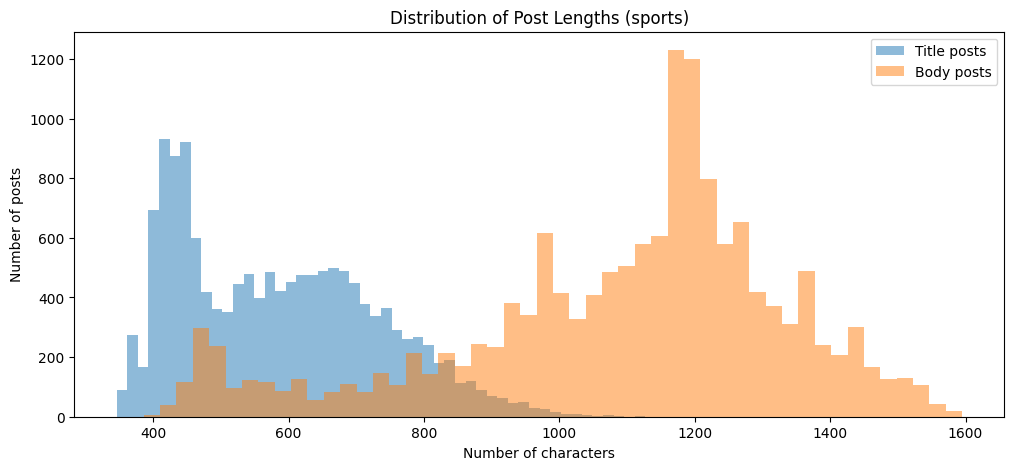

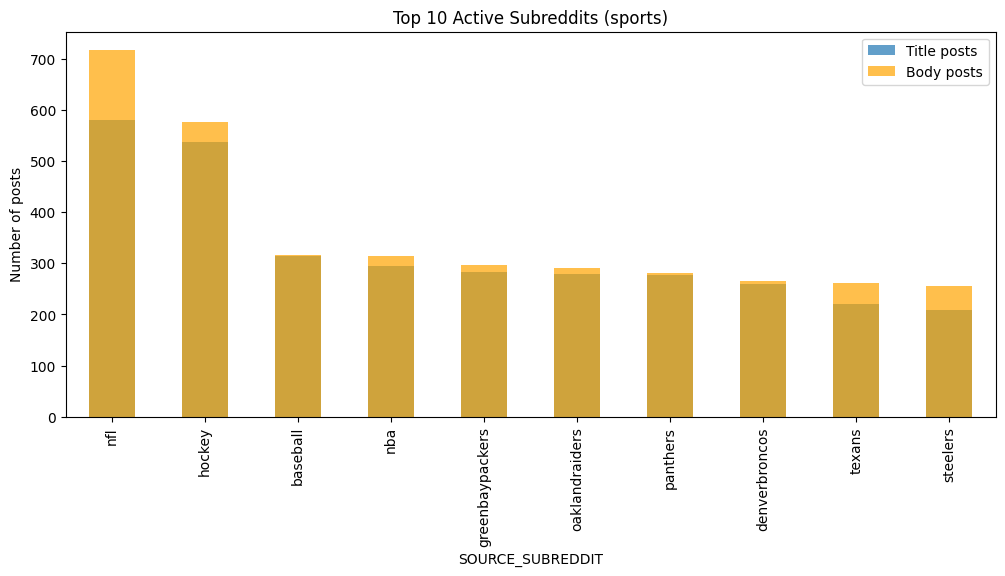

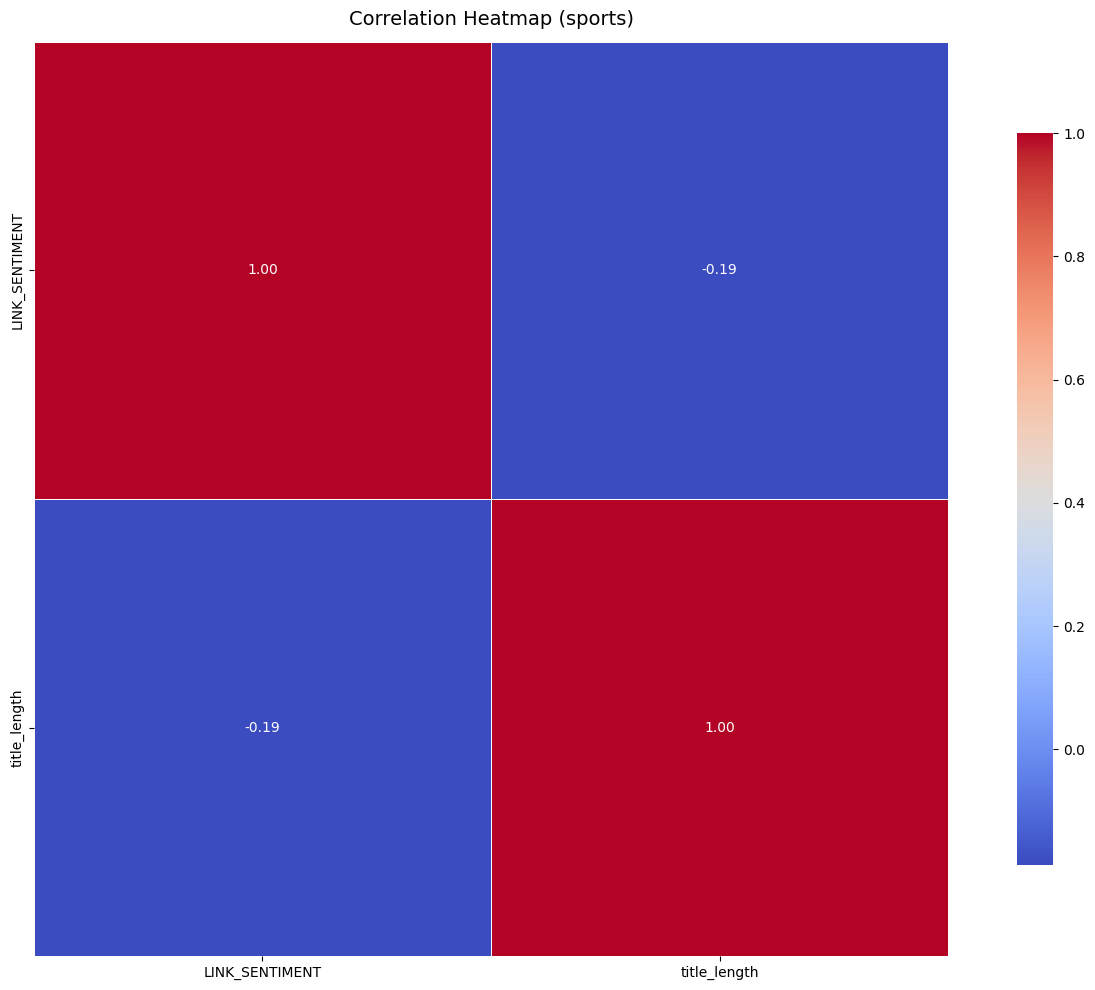


Detected spikes in Title sentiment (Z>2):
     Month  Sentiment   Z_score
0  2017-03         -1  3.041404

Detected spikes in Body sentiment (Z>2):
     Month  Sentiment   Z_score
0  2016-02          1  2.113773
1  2016-05         -1  4.666655
2  2017-02          1  3.634042
3  2017-03         -1  2.256921
4  2017-03          1  3.439698

Correlated Title spikes with events:
     Month  Sentiment   Z_score Date Event
0  2017-03         -1  3.041404  NaT   NaN

Correlated Body spikes with events:
     Month  Sentiment   Z_score     Date          Event
0  2016-02          1  2.113773  2016-02  Super Bowl 50
1  2016-05         -1  4.666655      NaT            NaN
2  2017-02          1  3.634042      NaT            NaN
3  2017-03         -1  2.256921      NaT            NaN
4  2017-03          1  3.439698      NaT            NaN


C:\Users\Arnau\AppData\Local\Temp\ipykernel_10112\1053526530.py:401: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


C:\Users\Arnau\AppData\Local\Temp\ipykernel_10112\1053526530.py:411: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



EDA completed for sports


In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from src.data import load_data

df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ]
}

# Dictionary to hold merged dataframes
merged_dfs = {}

# Merge with the neighbors found (centroid)
for theme_name, initial_subs in THEMES.items():
    neighbors_centroid_path = f'../data/{theme_name}_centroid_neighbors.csv'

    if os.path.exists(neighbors_centroid_path):
        neighbors_df = pd.read_csv(neighbors_centroid_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_centroid'] = merged_df
    else:
        print(f'File not found :( ')

    # Do the same for max similarity neighbors

    neighbors_maxsim_path = f'../data/{theme_name}_max_similarity_neighbors.csv'

    if os.path.exists(neighbors_maxsim_path):
        neighbors_df = pd.read_csv(neighbors_maxsim_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_maxsim'] = merged_df
    else:
        print(f'File not found :( ')

# Dataframes
sports_centroid_df = merged_dfs.get('sports_centroid')
# politics_centroid_df = merged_dfs.get('politics_centroid')
# gaming_centroid_df = merged_dfs.get('gaming_centroid')
sports_maxsim_df = merged_dfs.get('sports_maxsim')
# politics_maxsim_df = merged_dfs.get('politics_maxsim')
# gaming_maxsim_df = merged_dfs.get('gaming_maxsim')

print("Sports centroid shape:", sports_centroid_df.shape if sports_centroid_df is not None else "Not found")
print("Sports max similarity shape:", sports_maxsim_df.shape if sports_maxsim_df is not None else "Not found")

features = [
    "Number of characters",
    "Number of characters without counting white space",
    "Fraction of alphabetical characters",
    "Fraction of digits",
    "Fraction of uppercase characters",
    "Fraction of white spaces",
    "Fraction of special characters (e.g., comma, exclamation mark, etc.)",
    "Number of words",
    "Number of unique words",
    "Number of long words (at least 6 characters)",
    "Average word length",
    "Number of unique stopwords",
    "Fraction of stopwords",
    "Number of sentences",
    "Number of long sentences (at least 10 words)",
    "Average number of characters per sentence",
    "Average number of words per sentence",
    "Automated readability index",
    "Positive sentiment (VADER)",
    "Negative sentiment (VADER)",
    "Compound sentiment (VADER)",
    "LIWC_Funct",
    "LIWC_Pronoun",
    "LIWC_Ppron",
    "LIWC_I",
    "LIWC_We",
    "LIWC_You",
    "LIWC_SheHe",
    "LIWC_They",
    "LIWC_Ipron",
    "LIWC_Article",
    "LIWC_Verbs",
    "LIWC_AuxVb",
    "LIWC_Past",
    "LIWC_Present",
    "LIWC_Future",
    "LIWC_Adverbs",
    "LIWC_Prep",
    "LIWC_Conj",
    "LIWC_Negate",
    "LIWC_Quant",
    "LIWC_Numbers",
    "LIWC_Swear",
    "LIWC_Social",
    "LIWC_Family",
    "LIWC_Friends",
    "LIWC_Humans",
    "LIWC_Affect",
    "LIWC_Posemo",
    "LIWC_Negemo",
    "LIWC_Anx",
    "LIWC_Anger",
    "LIWC_Sad",
    "LIWC_CogMech",
    "LIWC_Insight",
    "LIWC_Cause",
    "LIWC_Discrep",
    "LIWC_Tentat",
    "LIWC_Certain",
    "LIWC_Inhib",
    "LIWC_Incl",
    "LIWC_Excl",
    "LIWC_Percept",
    "LIWC_See",
    "LIWC_Hear",
    "LIWC_Feel",
    "LIWC_Bio",
    "LIWC_Body",
    "LIWC_Health",
    "LIWC_Sexual",
    "LIWC_Ingest",
    "LIWC_Relativ",
    "LIWC_Motion",
    "LIWC_Space",
    "LIWC_Time",
    "LIWC_Work",
    "LIWC_Achiev",
    "LIWC_Leisure",
    "LIWC_Home",
    "LIWC_Money",
    "LIWC_Relig",
    "LIWC_Death",
    "LIWC_Assent",
    "LIWC_Dissent",
    "LIWC_Nonflu",
    "LIWC_Filler"
]

##################################################
# COMPUTE DIFFERENT LIWC ATTRIBUTES FOR EACH GROUP
##################################################

#######################################################
# AGGREGATE LIWC FEATURES PER SUBREDDIT AND TIME WINDOW
#######################################################

def get_dataframe_features(tf, tf2, subreddits_list):
    df_title_prop = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]

    df_body_prop = tf2[
        (
            tf2["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf2["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]
    raw_rows =[]
    for f in features[18:]:
        raw_rows.append((
            f,
            round(df_title_prop[f].mean(), 5),
            round(df_title_prop[f].max(), 2),
            round(df_title_prop[f].sum(), 2),
            round(df_title_prop[f].std(), 5),
            round(df_body_prop[f].mean(), 5),
            round(df_body_prop[f].max(), 2),
            round(df_body_prop[f].sum(), 2),
            round(df_body_prop[f].std(), 5),
        ))
    columns=["Feature", "Mean_Title", "Max_Title", "Sum_Title", "Std_Title", "Mean_Body", "Max_Body", "Sum_Body", "Std_Body"]
    df_features = pd.DataFrame(raw_rows, columns=columns)
    df_features_sentiment = df_features.loc[:2]
    df_features_liwc = df_features.loc[3:]
    return df_features_sentiment, df_features_liwc

####################################################################
# VISUALIZE SUBREDDIT ACTIVITY AND SENTIMENT DISTRIBUTIONS OVER TIME
####################################################################

def plot_subreddits_features_trend(tf, subreddits_list, start_time, end_time, features_list, period):

    period_map = { "D": "DAY", "W": "WEEK", "M": "MONTH", "Q": "QUARTER", "Y": "YEAR" }

    start_time = pd.Timestamp(start_time)
    end_time   = pd.Timestamp(end_time)
    
    # apply filters
    df = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
        & (tf["TIMESTAMP"] >= start_time)
        & (tf["TIMESTAMP"] <= end_time)
    ]
    df = df.assign(**{period_map[period]: df["TIMESTAMP"].dt.to_period(period)})


    period_stats = (
        df.groupby(period_map[period])[features_list]
        .sum()
        .assign(Count=df.groupby(period_map[period]).size())
    )
    period_stats.index = period_stats.index.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(16,6))

    # Bar plot for post count
    ax1.bar(period_stats.index, period_stats["Count"], color="gray", alpha=0.3)
    ax1.set_ylabel("Post Count", color="gray")
    ax1.set_xlabel(period_map[period])
    ax1.tick_params(axis="y")

    # Line plot for each sentiment on the second axis
    ax2 = ax1.twinx()
    for f in features_list:
        ax2.plot(period_stats.index, period_stats[f], label=f, linewidth=2)
    ax2.set_ylabel("Sum of Feature Values")
    ax2.tick_params(axis="y")

    # Title and legend
    plt.title(f"Sentiment {features_list}\n{period_map[period]} Trends ({start_time.date()} – {end_time.date()})\nwithin {subreddits_list}")
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes, title="Features")
    fig.tight_layout()
    plt.show()














################################################### Reusable EDA Pipeline ########################################################

import seaborn as sns
import numpy as np

# Filters title/body dataframes by subreddit list, prints summary info, and returns the filtered DataFrames
def basic_eda_summary(df_title, df_body, subreddits_list):

    df_title_filtered = df_title[
        (df_title["SOURCE_SUBREDDIT"].isin(subreddits_list)) |
        (df_title["TARGET_SUBREDDIT"].isin(subreddits_list))
    ].copy()

    df_body_filtered = df_body[
        (df_body["SOURCE_SUBREDDIT"].isin(subreddits_list)) |
        (df_body["TARGET_SUBREDDIT"].isin(subreddits_list))
    ].copy()

    print("\nBASIC SUMMARY:")
    print(f"Filtered title posts: {df_title_filtered.shape[0]}")
    print(f"Filtered body posts: {df_body_filtered.shape[0]}")
    print(f"Unique subreddits analyzed: {len(subreddits_list)}")

    if "LINK_SENTIMENT" in df_title_filtered.columns:
        print("\nTitle sentiment distribution:")
        print(df_title_filtered["LINK_SENTIMENT"].value_counts(normalize=True))

    if "LINK_SENTIMENT" in df_body_filtered.columns:
        print("\nBody sentiment distribution:")
        print(df_body_filtered["LINK_SENTIMENT"].value_counts(normalize=True))

    return df_title_filtered, df_body_filtered

# Define real-world events for sports
def get_sports_events():
    events_data = [
        {"Date": "2013-12-01", "Event": "NBA Regular Season Start"},
        {"Date": "2014-02-02", "Event": "Super Bowl XLVIII"},
        {"Date": "2015-06-01", "Event": "NBA Finals"},
        {"Date": "2016-02-07", "Event": "Super Bowl 50"},
        {"Date": "2017-04-10", "Event": "NBA Playoffs Begin"}
    ]
    events_df = pd.DataFrame(events_data)
    events_df["Date"] = pd.to_datetime(events_df["Date"]).dt.to_period("M")
    return events_df

# Standard EDA visualizations on filtered DataFrames
def extended_eda(df_title_filtered, df_body_filtered, theme_name="Theme"):

    print("\nMISSING VALUES:")
    print(df_title_filtered.isnull().sum())
    print(df_body_filtered.isnull().sum())

    # Distribution of text length
    for df, label in [(df_title_filtered, "Title"), (df_body_filtered, "Body")]:
        if 'PROPERTIES' in df.columns:
            df[f'{label.lower()}_length'] = df['PROPERTIES'].astype(str).str.len()

    plt.figure(figsize=(12, 5))
    plt.hist(df_title_filtered.get('title_length', []), bins=50, alpha=0.5, label='Title posts')
    plt.hist(df_body_filtered.get('body_length', []), bins=50, alpha=0.5, label='Body posts')
    plt.xlabel('Number of characters')
    plt.ylabel('Number of posts')
    plt.title(f'Distribution of Post Lengths ({theme_name})')
    plt.legend()
    plt.show()

    # Top active subreddits
    top_title = df_title_filtered['SOURCE_SUBREDDIT'].value_counts().head(10)
    top_body = df_body_filtered['SOURCE_SUBREDDIT'].value_counts().head(10)

    plt.figure(figsize=(12, 5))
    top_title.plot(kind='bar', alpha=0.7, label='Title posts')
    top_body.plot(kind='bar', alpha=0.7, color='orange', label='Body posts')
    plt.ylabel('Number of posts')
    plt.title(f'Top 10 Active Subreddits ({theme_name})')
    plt.legend()
    plt.show()

    # Correlation heatmap for numeric features
    numeric_cols = df_title_filtered.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(14, 10))
        corr_matrix = df_title_filtered[numeric_cols].corr()
        sns.heatmap(
            corr_matrix,
            annot=True,              # show correlation values
            fmt=".2f",               # two decimals
            cmap="coolwarm",         # color palette
            linewidths=0.5,          # grid lines between squares
            square=True,             # equal aspect ratio for squares
            cbar_kws={"shrink": 0.8}
        )
        plt.title(f'Correlation Heatmap ({theme_name})', fontsize=14, pad=12)
        plt.tight_layout()
        plt.show()

    # Monthly LINK_SENTIMENT trends
    if "TIMESTAMP" in df_title_filtered.columns and "LINK_SENTIMENT" in df_title_filtered.columns:
        df_title_filtered["month"] = df_title_filtered["TIMESTAMP"].dt.to_period("M")
        df_body_filtered["month"] = df_body_filtered["TIMESTAMP"].dt.to_period("M")

        title_sent = df_title_filtered.groupby(["month", "LINK_SENTIMENT"]).size().unstack(fill_value=0)
        body_sent = df_body_filtered.groupby(["month", "LINK_SENTIMENT"]).size().unstack(fill_value=0)

        # Z-score computation
        title_z = (title_sent - title_sent.mean()) / title_sent.std()
        body_z = (body_sent - body_sent.mean()) / body_sent.std()

        # Detect spikes
        title_spikes = title_z[title_z > 2].stack().reset_index()
        title_spikes.columns = ['Month', 'Sentiment', 'Z_score']

        body_spikes = body_z[body_z > 2].stack().reset_index()
        body_spikes.columns = ['Month', 'Sentiment', 'Z_score']

        print("\nDetected spikes in Title sentiment (Z>2):")
        print(title_spikes)
        print("\nDetected spikes in Body sentiment (Z>2):")
        print(body_spikes)

        # Correlate spikes with real-world events
        events_df = get_sports_events()
        title_spikes_events = pd.merge(title_spikes, events_df, left_on='Month', right_on='Date', how='left')
        body_spikes_events = pd.merge(body_spikes, events_df, left_on='Month', right_on='Date', how='left')

        print("\nCorrelated Title spikes with events:")
        print(title_spikes_events)
        print("\nCorrelated Body spikes with events:")
        print(body_spikes_events)

        # Plot Title sentiment with event annotations
        title_sent.plot(kind="bar", stacked=True, figsize=(14, 5), title=f"Monthly Sentiment (Title Posts - {theme_name})")
        for _, row in events_df.iterrows():
            plt.axvline(row['Date'].to_timestamp(), color='red', linestyle='--', alpha=0.5)
            plt.text(row['Date'].to_timestamp(), title_sent.values.max()*1.02, row['Event'], rotation=90, color='red', fontsize=9, ha='center')
        plt.xlabel("Month")
        plt.ylabel("Post count")
        plt.tight_layout()
        plt.show()

        # Plot Body sentiment with event annotations
        body_sent.plot(kind="bar", stacked=True, figsize=(14, 5), title=f"Monthly Sentiment (Body Posts - {theme_name})", color=['red','green','blue'])
        for _, row in events_df.iterrows():
            plt.axvline(row['Date'].to_timestamp(), color='red', linestyle='--', alpha=0.5)
            plt.text(row['Date'].to_timestamp(), body_sent.values.max()*1.02, row['Event'], rotation=90, color='red', fontsize=9, ha='center')
        plt.xlabel("Month")
        plt.ylabel("Post count")
        plt.tight_layout()
        plt.show()

    # Aggregate LIWC features per subreddit over time
    liwc_cols = [c for c in df_title_filtered.columns if c.startswith("LIWC_")]
    if liwc_cols:
        liwc_avg = df_title_filtered.groupby("SOURCE_SUBREDDIT")[liwc_cols].mean()
        print(f"\nAverage LIWC features per subreddit ({theme_name}):")
        print(liwc_avg.head(10))
        plt.figure(figsize=(14, 8))
        sns.heatmap(liwc_avg, annot=False, cmap="viridis")
        plt.title(f'Average LIWC Features per Subreddit ({theme_name})')
        plt.xlabel('LIWC Feature')
        plt.ylabel('Subreddit')
        plt.show()

# Full EDA pipeline
def run_eda_pipeline(theme_name, df_title, df_body, theme_df):
 
    print(f"\nRUNNING EDA FOR {theme_name.upper()}")

    if theme_df is None or theme_df.empty:
        print(f"No data available for {theme_name} --> Skipping")
        return

    subreddits_list = theme_df['SUBREDDIT'].tolist()
    df_title_filt, df_body_filt = basic_eda_summary(df_title, df_body, subreddits_list)
    extended_eda(df_title_filt, df_body_filt, theme_name=theme_name)
    print(f"\nEDA completed for {theme_name}")

################################ Run the EDA for the sports theme #################################
run_eda_pipeline("sports", df_title, df_body, sports_centroid_df)


Sports centroid shape: (122, 301)
Sports max similarity shape: (122, 301)

RUNNING EDA FOR SPORTS

BASIC SUMMARY:
Filtered title posts: 14406
Filtered body posts: 15113
Unique subreddits analyzed: 122

Title sentiment distribution:
LINK_SENTIMENT
 1    0.922879
-1    0.077121
Name: proportion, dtype: float64

Body sentiment distribution:
LINK_SENTIMENT
 1    0.975716
-1    0.024284
Name: proportion, dtype: float64

MISSING VALUES:
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
PROPERTIES          0
dtype: int64
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
PROPERTIES          0
dtype: int64


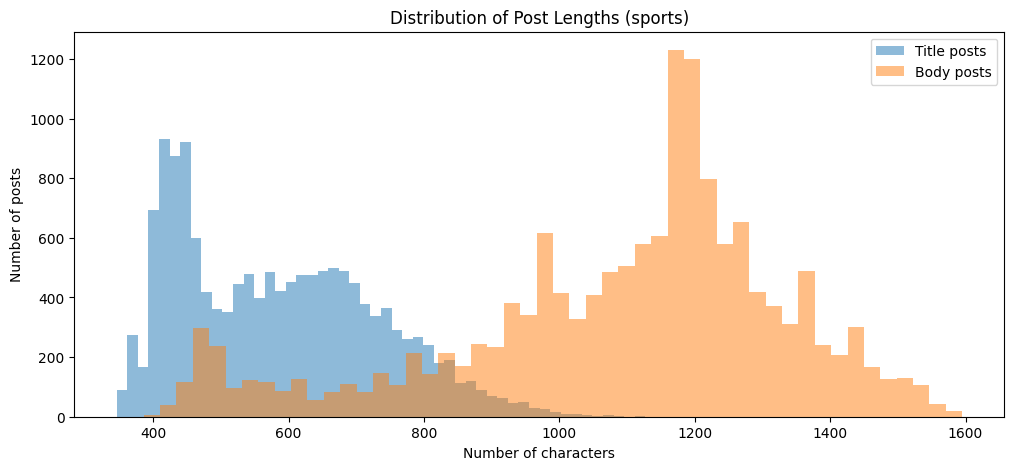

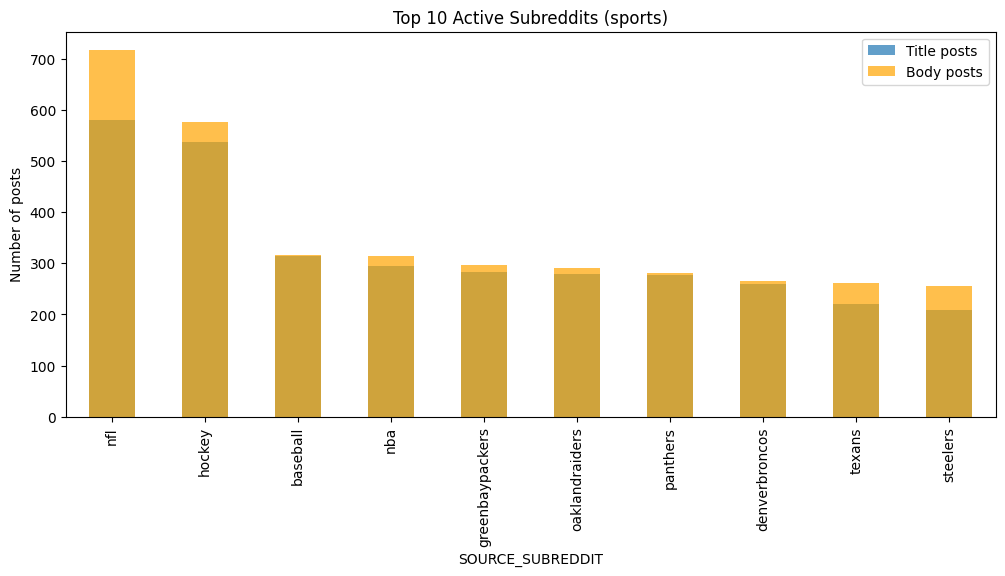

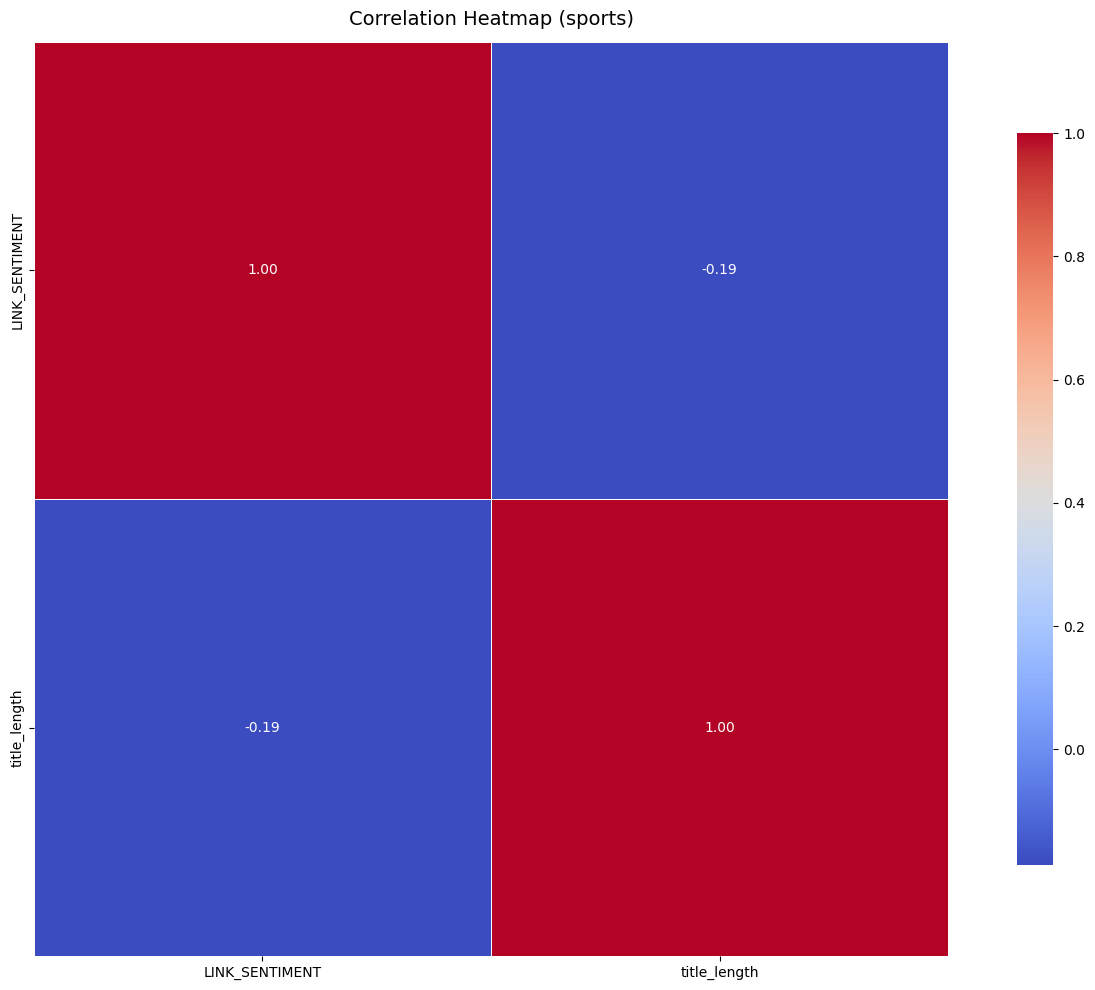


Detected spikes in Title sentiment (Z>2):
     Month  Sentiment   Z_score
0  2017-03         -1  3.041404

Detected spikes in Body sentiment (Z>2):
     Month  Sentiment   Z_score
0  2016-02          1  2.113773
1  2016-05         -1  4.666655
2  2017-02          1  3.634042
3  2017-03         -1  2.256921
4  2017-03          1  3.439698

Correlated Title spikes with events:
     Month  Sentiment   Z_score   Month_ts               Event Event_Date
0  2017-03         -1  3.041404 2017-03-01  NBA Playoffs Begin 2017-04-01

Correlated Body spikes with events:
     Month  Sentiment   Z_score   Month_ts               Event Event_Date
0  2016-02          1  2.113773 2016-02-01       Super Bowl 50 2016-02-01
1  2016-05         -1  4.666655 2016-05-01                None        NaT
2  2017-02          1  3.634042 2017-02-01                None        NaT
3  2017-03         -1  2.256921 2017-03-01  NBA Playoffs Begin 2017-04-01
4  2017-03          1  3.439698 2017-03-01  NBA Playoffs Begin 201


EDA completed for sports


In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from src.data import load_data

df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ]
}

# Dictionary to hold merged dataframes
merged_dfs = {}

# Merge with the neighbors found (centroid)
for theme_name, initial_subs in THEMES.items():
    neighbors_centroid_path = f'../data/{theme_name}_centroid_neighbors.csv'

    if os.path.exists(neighbors_centroid_path):
        neighbors_df = pd.read_csv(neighbors_centroid_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_centroid'] = merged_df
    else:
        print(f'File not found :( ')

    # Do the same for max similarity neighbors

    neighbors_maxsim_path = f'../data/{theme_name}_max_similarity_neighbors.csv'

    if os.path.exists(neighbors_maxsim_path):
        neighbors_df = pd.read_csv(neighbors_maxsim_path)

        # Put all names in a list to filter duplicates
        merged_list = list(set(initial_subs + neighbors_df['SUBREDDIT'].tolist()))

        # Get the corresponding embeddings
        merged_df = df_subreddits[df_subreddits['SUBREDDIT'].isin(merged_list)].copy()

        # Save in dictionary for later use
        merged_dfs[f'{theme_name}_maxsim'] = merged_df
    else:
        print(f'File not found :( ')

# Dataframes
sports_centroid_df = merged_dfs.get('sports_centroid')
# politics_centroid_df = merged_dfs.get('politics_centroid')
# gaming_centroid_df = merged_dfs.get('gaming_centroid')
sports_maxsim_df = merged_dfs.get('sports_maxsim')
# politics_maxsim_df = merged_dfs.get('politics_maxsim')
# gaming_maxsim_df = merged_dfs.get('gaming_maxsim')

print("Sports centroid shape:", sports_centroid_df.shape if sports_centroid_df is not None else "Not found")
print("Sports max similarity shape:", sports_maxsim_df.shape if sports_maxsim_df is not None else "Not found")

features = [
    "Number of characters",
    "Number of characters without counting white space",
    "Fraction of alphabetical characters",
    "Fraction of digits",
    "Fraction of uppercase characters",
    "Fraction of white spaces",
    "Fraction of special characters (e.g., comma, exclamation mark, etc.)",
    "Number of words",
    "Number of unique words",
    "Number of long words (at least 6 characters)",
    "Average word length",
    "Number of unique stopwords",
    "Fraction of stopwords",
    "Number of sentences",
    "Number of long sentences (at least 10 words)",
    "Average number of characters per sentence",
    "Average number of words per sentence",
    "Automated readability index",
    "Positive sentiment (VADER)",
    "Negative sentiment (VADER)",
    "Compound sentiment (VADER)",
    "LIWC_Funct",
    "LIWC_Pronoun",
    "LIWC_Ppron",
    "LIWC_I",
    "LIWC_We",
    "LIWC_You",
    "LIWC_SheHe",
    "LIWC_They",
    "LIWC_Ipron",
    "LIWC_Article",
    "LIWC_Verbs",
    "LIWC_AuxVb",
    "LIWC_Past",
    "LIWC_Present",
    "LIWC_Future",
    "LIWC_Adverbs",
    "LIWC_Prep",
    "LIWC_Conj",
    "LIWC_Negate",
    "LIWC_Quant",
    "LIWC_Numbers",
    "LIWC_Swear",
    "LIWC_Social",
    "LIWC_Family",
    "LIWC_Friends",
    "LIWC_Humans",
    "LIWC_Affect",
    "LIWC_Posemo",
    "LIWC_Negemo",
    "LIWC_Anx",
    "LIWC_Anger",
    "LIWC_Sad",
    "LIWC_CogMech",
    "LIWC_Insight",
    "LIWC_Cause",
    "LIWC_Discrep",
    "LIWC_Tentat",
    "LIWC_Certain",
    "LIWC_Inhib",
    "LIWC_Incl",
    "LIWC_Excl",
    "LIWC_Percept",
    "LIWC_See",
    "LIWC_Hear",
    "LIWC_Feel",
    "LIWC_Bio",
    "LIWC_Body",
    "LIWC_Health",
    "LIWC_Sexual",
    "LIWC_Ingest",
    "LIWC_Relativ",
    "LIWC_Motion",
    "LIWC_Space",
    "LIWC_Time",
    "LIWC_Work",
    "LIWC_Achiev",
    "LIWC_Leisure",
    "LIWC_Home",
    "LIWC_Money",
    "LIWC_Relig",
    "LIWC_Death",
    "LIWC_Assent",
    "LIWC_Dissent",
    "LIWC_Nonflu",
    "LIWC_Filler"
]

##################################################
# COMPUTE DIFFERENT LIWC ATTRIBUTES FOR EACH GROUP
##################################################

#######################################################
# AGGREGATE LIWC FEATURES PER SUBREDDIT AND TIME WINDOW
#######################################################

def get_dataframe_features(tf, tf2, subreddits_list):
    df_title_prop = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]

    df_body_prop = tf2[
        (
            tf2["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf2["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
    ]
    raw_rows =[]
    for f in features[18:]:
        raw_rows.append((
            f,
            round(df_title_prop[f].mean(), 5),
            round(df_title_prop[f].max(), 2),
            round(df_title_prop[f].sum(), 2),
            round(df_title_prop[f].std(), 5),
            round(df_body_prop[f].mean(), 5),
            round(df_body_prop[f].max(), 2),
            round(df_body_prop[f].sum(), 2),
            round(df_body_prop[f].std(), 5),
        ))
    columns=["Feature", "Mean_Title", "Max_Title", "Sum_Title", "Std_Title", "Mean_Body", "Max_Body", "Sum_Body", "Std_Body"]
    df_features = pd.DataFrame(raw_rows, columns=columns)
    df_features_sentiment = df_features.loc[:2]
    df_features_liwc = df_features.loc[3:]
    return df_features_sentiment, df_features_liwc

####################################################################
# VISUALIZE SUBREDDIT ACTIVITY AND SENTIMENT DISTRIBUTIONS OVER TIME
####################################################################

def plot_subreddits_features_trend(tf, subreddits_list, start_time, end_time, features_list, period):

    period_map = { "D": "DAY", "W": "WEEK", "M": "MONTH", "Q": "QUARTER", "Y": "YEAR" }

    start_time = pd.Timestamp(start_time)
    end_time   = pd.Timestamp(end_time)
    
    # apply filters
    df = tf[
        (
            tf["SOURCE_SUBREDDIT"].isin(subreddits_list) |
            tf["TARGET_SUBREDDIT"].isin(subreddits_list)
        )
        & (tf["TIMESTAMP"] >= start_time)
        & (tf["TIMESTAMP"] <= end_time)
    ]
    df = df.assign(**{period_map[period]: df["TIMESTAMP"].dt.to_period(period)})


    period_stats = (
        df.groupby(period_map[period])[features_list]
        .sum()
        .assign(Count=df.groupby(period_map[period]).size())
    )
    period_stats.index = period_stats.index.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(16,6))

    # Bar plot for post count
    ax1.bar(period_stats.index, period_stats["Count"], color="gray", alpha=0.3)
    ax1.set_ylabel("Post Count", color="gray")
    ax1.set_xlabel(period_map[period])
    ax1.tick_params(axis="y")

    # Line plot for each sentiment on the second axis
    ax2 = ax1.twinx()
    for f in features_list:
        ax2.plot(period_stats.index, period_stats[f], label=f, linewidth=2)
    ax2.set_ylabel("Sum of Feature Values")
    ax2.tick_params(axis="y")

    # Title and legend
    plt.title(f"Sentiment {features_list}\n{period_map[period]} Trends ({start_time.date()} – {end_time.date()})\nwithin {subreddits_list}")
    fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes, title="Features")
    fig.tight_layout()
    plt.show()














################################################### Reusable EDA Pipeline ########################################################

import seaborn as sns
import numpy as np

# Filters title/body dataframes by subreddit list, prints summary info, and returns the filtered DataFrames
def basic_eda_summary(df_title, df_body, subreddits_list):

    df_title_filtered = df_title[
        (df_title["SOURCE_SUBREDDIT"].isin(subreddits_list)) |
        (df_title["TARGET_SUBREDDIT"].isin(subreddits_list))
    ].copy()

    df_body_filtered = df_body[
        (df_body["SOURCE_SUBREDDIT"].isin(subreddits_list)) |
        (df_body["TARGET_SUBREDDIT"].isin(subreddits_list))
    ].copy()

    print("\nBASIC SUMMARY:")
    print(f"Filtered title posts: {df_title_filtered.shape[0]}")
    print(f"Filtered body posts: {df_body_filtered.shape[0]}")
    print(f"Unique subreddits analyzed: {len(subreddits_list)}")

    if "LINK_SENTIMENT" in df_title_filtered.columns:
        print("\nTitle sentiment distribution:")
        print(df_title_filtered["LINK_SENTIMENT"].value_counts(normalize=True))

    if "LINK_SENTIMENT" in df_body_filtered.columns:
        print("\nBody sentiment distribution:")
        print(df_body_filtered["LINK_SENTIMENT"].value_counts(normalize=True))

    return df_title_filtered, df_body_filtered

# Define real-world events for sports
def get_sports_events():
    events_data = [
        {"Date": "2013-12-01", "Event": "NBA Regular Season Start"},
        {"Date": "2014-02-02", "Event": "Super Bowl XLVIII"},
        {"Date": "2015-06-01", "Event": "NBA Finals"},
        {"Date": "2016-02-07", "Event": "Super Bowl 50"},
        {"Date": "2017-04-10", "Event": "NBA Playoffs Begin"}
    ]
    events_df = pd.DataFrame(events_data)
    events_df["Date"] = pd.to_datetime(events_df["Date"]).dt.to_period("M")
    return events_df

##############################################################
# IDENTIFY SPIKES OR ANOMALIES ALIGNED WITH MAJOR WORLD EVENTS
##############################################################

# Standard EDA visualizations on filtered DataFrames
def extended_eda(df_title_filtered, df_body_filtered, theme_name="Theme"):

    print("\nMISSING VALUES:")
    print(df_title_filtered.isnull().sum())
    print(df_body_filtered.isnull().sum())

    # Distribution of text length
    for df, label in [(df_title_filtered, "Title"), (df_body_filtered, "Body")]:
        if 'PROPERTIES' in df.columns:
            df[f'{label.lower()}_length'] = df['PROPERTIES'].astype(str).str.len()

    plt.figure(figsize=(12, 5))
    plt.hist(df_title_filtered.get('title_length', []), bins=50, alpha=0.5, label='Title posts')
    plt.hist(df_body_filtered.get('body_length', []), bins=50, alpha=0.5, label='Body posts')
    plt.xlabel('Number of characters')
    plt.ylabel('Number of posts')
    plt.title(f'Distribution of Post Lengths ({theme_name})')
    plt.legend()
    plt.show()

    # Top active subreddits
    top_title = df_title_filtered['SOURCE_SUBREDDIT'].value_counts().head(10)
    top_body = df_body_filtered['SOURCE_SUBREDDIT'].value_counts().head(10)

    plt.figure(figsize=(12, 5))
    top_title.plot(kind='bar', alpha=0.7, label='Title posts')
    top_body.plot(kind='bar', alpha=0.7, color='orange', label='Body posts')
    plt.ylabel('Number of posts')
    plt.title(f'Top 10 Active Subreddits ({theme_name})')
    plt.legend()
    plt.show()

    # Correlation heatmap for numeric features
    numeric_cols = df_title_filtered.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(14, 10))
        corr_matrix = df_title_filtered[numeric_cols].corr()
        sns.heatmap(
            corr_matrix,
            annot=True,               # show correlation values
            fmt=".2f",                # two decimals
            cmap="coolwarm",          # color palette
            linewidths=0.5,           # grid lines between squares
            square=True,              # equal aspect ratio for squares
            cbar_kws={"shrink": 0.8}
        )
        plt.title(f'Correlation Heatmap ({theme_name})', fontsize=14, pad=12)
        plt.tight_layout()
        plt.show()

    # Monthly LINK_SENTIMENT trends
    if "TIMESTAMP" in df_title_filtered.columns and "LINK_SENTIMENT" in df_title_filtered.columns:
        df_title_filtered["month"] = df_title_filtered["TIMESTAMP"].dt.to_period("M")
        df_body_filtered["month"] = df_body_filtered["TIMESTAMP"].dt.to_period("M")

        title_sent = df_title_filtered.groupby(["month", "LINK_SENTIMENT"]).size().unstack(fill_value=0)
        body_sent = df_body_filtered.groupby(["month", "LINK_SENTIMENT"]).size().unstack(fill_value=0)

        # Z-score computation
        title_z = (title_sent - title_sent.mean()) / title_sent.std()
        body_z = (body_sent - body_sent.mean()) / body_sent.std()

        # Detect spikes
        title_spikes = title_z[title_z > 2].stack().reset_index()
        title_spikes.columns = ['Month', 'Sentiment', 'Z_score']

        body_spikes = body_z[body_z > 2].stack().reset_index()
        body_spikes.columns = ['Month', 'Sentiment', 'Z_score']

        print("\nDetected spikes in Title sentiment (Z>2):")
        print(title_spikes)
        print("\nDetected spikes in Body sentiment (Z>2):")
        print(body_spikes)

        # Correlate spikes with events using nearest month
        events_df = get_sports_events()
        events_df['Date_ts'] = events_df['Date'].dt.to_timestamp()
        
        def match_nearest_event(spikes_df):
            spikes_df = spikes_df.copy()
            spikes_df['Month_ts'] = spikes_df['Month'].dt.to_timestamp()
            spikes_df['Event'] = None
            spikes_df['Event_Date'] = pd.NaT

            for i, row in spikes_df.iterrows():
                # find nearest event within ±1 month
                deltas = abs(events_df['Date_ts'] - row['Month_ts'])
                if deltas.min() <= pd.Timedelta(days=31):
                    idx = deltas.idxmin()
                    spikes_df.at[i, 'Event'] = events_df.at[idx, 'Event']
                    spikes_df.at[i, 'Event_Date'] = events_df.at[idx, 'Date_ts']
            return spikes_df

        title_spikes_events = match_nearest_event(title_spikes)
        body_spikes_events = match_nearest_event(body_spikes)

        print("\nCorrelated Title spikes with events:")
        print(title_spikes_events)
        print("\nCorrelated Body spikes with events:")
        print(body_spikes_events)

        # Plotting with annotated spikes
        def plot_sentiment_with_events(sent_df, spikes_df, theme_name, plot_type="Title", colors=None):
            sent_df.plot(kind="bar", stacked=True, figsize=(16, 6), color=colors)
            plt.xlabel("Month")
            plt.ylabel("Post count")
            plt.title(f"Monthly Sentiment ({plot_type} Posts - {theme_name})")

            for i, row in spikes_df.iterrows():
                if pd.notnull(row['Event_Date']):
                    plt.axvline(row['Month_ts'], color='red', linestyle='--', alpha=0.5)
                    plt.text(
                        row['Month_ts'], 
                        sent_df.max().max()*1.05, 
                        row['Event'], 
                        rotation=90, 
                        verticalalignment='bottom',
                        fontsize=9,
                        color='red'
                    )
            plt.subplots_adjust(left=0.05, right=0.95)
            plt.show()

        plot_sentiment_with_events(title_sent, title_spikes_events, theme_name, plot_type="Title")
        plot_sentiment_with_events(body_sent, body_spikes_events, theme_name, plot_type="Body", colors=['red','green','blue'])

    # Aggregate LIWC features per subreddit over time
    liwc_cols = [c for c in df_title_filtered.columns if c.startswith("LIWC_")]
    if liwc_cols:
        liwc_avg = df_title_filtered.groupby("SOURCE_SUBREDDIT")[liwc_cols].mean()
        print(f"\nAverage LIWC features per subreddit ({theme_name}):")
        print(liwc_avg.head(10))
        plt.figure(figsize=(14, 8))
        sns.heatmap(liwc_avg, annot=False, cmap="viridis")
        plt.title(f'Average LIWC Features per Subreddit ({theme_name})')
        plt.xlabel('LIWC Feature')
        plt.ylabel('Subreddit')
        plt.show()


###################
# Full EDA pipeline
###################

def run_eda_pipeline(theme_name, df_title, df_body, theme_df):
 
    print(f"\nRUNNING EDA FOR {theme_name.upper()}")

    if theme_df is None or theme_df.empty:
        print(f"No data available for {theme_name} --> Skipping")
        return

    subreddits_list = theme_df['SUBREDDIT'].tolist()
    df_title_filt, df_body_filt = basic_eda_summary(df_title, df_body, subreddits_list)
    extended_eda(df_title_filt, df_body_filt, theme_name=theme_name)
    print(f"\nEDA completed for {theme_name}")


################################ Run the EDA for the sports theme #################################
run_eda_pipeline("sports", df_title, df_body, sports_centroid_df)



In [9]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Add src folder to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

# Import internal modules
from src.data import load_data
from src.consts import *
from src.preprocessing import filter_active_subreddits
from src.similarity import similar_by_centroid, similar_by_max_similarity
from src.visualization import (
    set_plt_style,
    plot_activity_over_time,
    plot_liwc_heatmaps,
    plot_subreddits_properties_trend,
)
from src.utils import parse_properties

# -----------------------------
# Helper: parse properties in chunks
# -----------------------------
def parse_properties_lazy(df, chunk_size=10000):
    dfs = []
    for start in range(0, len(df), chunk_size):
        chunk = df.iloc[start:start+chunk_size].copy()
        dfs.append(parse_properties(chunk))
    return pd.concat(dfs, ignore_index=True)

# -----------------------------
# Load data (holidays removed, avoid parsing inside load_data)
# -----------------------------
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

# -----------------------------
# Define themes
# -----------------------------
THEMES = {
    'sports': [
        'nba', 'nfl', 'hockey', 'fantasyfootball', 'cfb', 'maddenultimateteam', 
        'baseball', 'golf', 'patriots', 'collegebasketball', 'seahawks', 
        'minnesotavikings', 'madden', 'greenbaypackers', 'warriors', 'eagles', 
        'denverbroncos', 'torontobluejays', '49ers', 'lakers', 'browns', 'oaklandraiders'
    ]
}

# -----------------------------
# Merge picked subreddits with neighbors
# -----------------------------
def merge_theme_neighbors(theme_name, initial_subs, df_subreddits, top_n=SIMILARITY_N_CLUSTERS):
    merged_dfs = {}

    # Centroid similarity
    centroid_neighbors = similar_by_centroid(initial_subs, df_subreddits, top_n=top_n)
    centroid_list = list(set(initial_subs + centroid_neighbors['SUBREDDIT'].tolist()))
    merged_dfs[f'{theme_name}_centroid'] = df_subreddits[df_subreddits['SUBREDDIT'].isin(centroid_list)].copy()

    # Max similarity
    maxsim_neighbors = similar_by_max_similarity(initial_subs, df_subreddits, top_n=top_n)
    maxsim_list = list(set(initial_subs + maxsim_neighbors['SUBREDDIT'].tolist()))
    merged_dfs[f'{theme_name}_maxsim'] = df_subreddits[df_subreddits['SUBREDDIT'].isin(maxsim_list)].copy()

    return merged_dfs

all_merged_dfs = {}
for theme_name, initial_subs in THEMES.items():
    theme_merged = merge_theme_neighbors(theme_name, initial_subs, df_subreddits)
    all_merged_dfs.update(theme_merged)

sports_centroid_df = all_merged_dfs.get('sports_centroid')
sports_maxsim_df  = all_merged_dfs.get('sports_maxsim')

print("Sports centroid shape:", sports_centroid_df.shape if sports_centroid_df is not None else "Not found")
print("Sports max similarity shape:", sports_maxsim_df.shape if sports_maxsim_df is not None else "Not found")

# -----------------------------
# Filter posts first to speed up parsing
# -----------------------------
subreddits_list = sports_centroid_df['SUBREDDIT'].tolist()

df_title_small = df_title[
    df_title['SOURCE_SUBREDDIT'].isin(subreddits_list) | df_title['TARGET_SUBREDDIT'].isin(subreddits_list)
].copy()

df_body_small = df_body[
    df_body['SOURCE_SUBREDDIT'].isin(subreddits_list) | df_body['TARGET_SUBREDDIT'].isin(subreddits_list)
].copy()

# -----------------------------
# Lazy parse only filtered posts
# -----------------------------
df_title_parsed = parse_properties_lazy(df_title_small)
df_body_parsed  = parse_properties_lazy(df_body_small)

# -----------------------------
# EDA pipeline
# -----------------------------
def run_eda(theme_name, df_title, df_body, theme_df):
    if theme_df is None or theme_df.empty:
        print(f"No data available for {theme_name} --> Skipping")
        return
    
    subreddits_list = theme_df['SUBREDDIT'].tolist()

    df_title_filtered = df_title[
        df_title['SOURCE_SUBREDDIT'].isin(subreddits_list) | df_title['TARGET_SUBREDDIT'].isin(subreddits_list)
    ]
    df_body_filtered = df_body[
        df_body['SOURCE_SUBREDDIT'].isin(subreddits_list) | df_body['TARGET_SUBREDDIT'].isin(subreddits_list)
    ]

    print(f"\nEDA for {theme_name.upper()}")
    print(f"Filtered title posts: {df_title_filtered.shape[0]}")
    print(f"Filtered body posts: {df_body_filtered.shape[0]}")
    print(f"Unique subreddits: {len(subreddits_list)}")

    # Plot activity
    set_plt_style()
    plot_activity_over_time(df_title_filtered, pattern=subreddits_list)
    plot_activity_over_time(df_body_filtered, pattern=subreddits_list)

    # LIWC heatmaps
    fig, ax = plt.subplots(figsize=(14,8))
    plot_liwc_heatmaps(ax, df_title_filtered, subreddits_list)
    plt.show()

    # Trend over time for sentiment
    features_list = ["Positive sentiment (VADER)", "Negative sentiment (VADER)", "Compound sentiment (VADER)"]
    fig, ax = plt.subplots(figsize=(16,6))
    plot_subreddits_properties_trend(ax, df_title_filtered, subreddits_list, DATA_START_DATE, DATA_END_DATE, features_list, period="M")
    plt.show()

# -----------------------------
# Run EDA for sports theme (centroid neighbors)
# -----------------------------
run_eda("sports", df_title_parsed, df_body_parsed, sports_centroid_df)


Sports centroid shape: (122, 301)
Sports max similarity shape: (122, 301)


KeyError: 'PROPERTIES'